# Exploratory Data Analysis (EDA) - Telco Customer Churn

This notebook covers the Exploratory Data Analysis for the Telco Customer Churn Dataset. We will perform the following:
1. Load and inspect the dataset
2. Visualize the distribution of Churn (the target variable)
3. Analyze demographic features
4. Analyze account/service-related features
5. Analyze numeric variables and correlation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

## 1. Load and Inspect Data

In [13]:
# Load dataset
df = pd.read_csv('../data/Telco_Customer_Churn_Dataset.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
# Inspect basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [14]:
# Clean TotalCharges: handle empty strings and convert to float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


## 2. Target Variable (Churn) Distribution

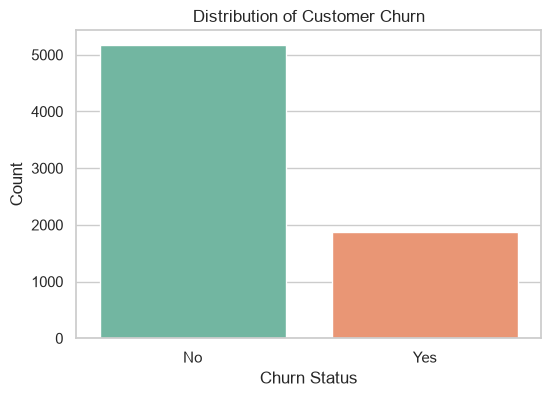

In [16]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='Set2', hue='Churn', legend=False)
plt.title('Distribution of Customer Churn')
plt.xlabel('Churn Status')
plt.ylabel('Count')
plt.show()

## 3. Demographic Features vs Churn

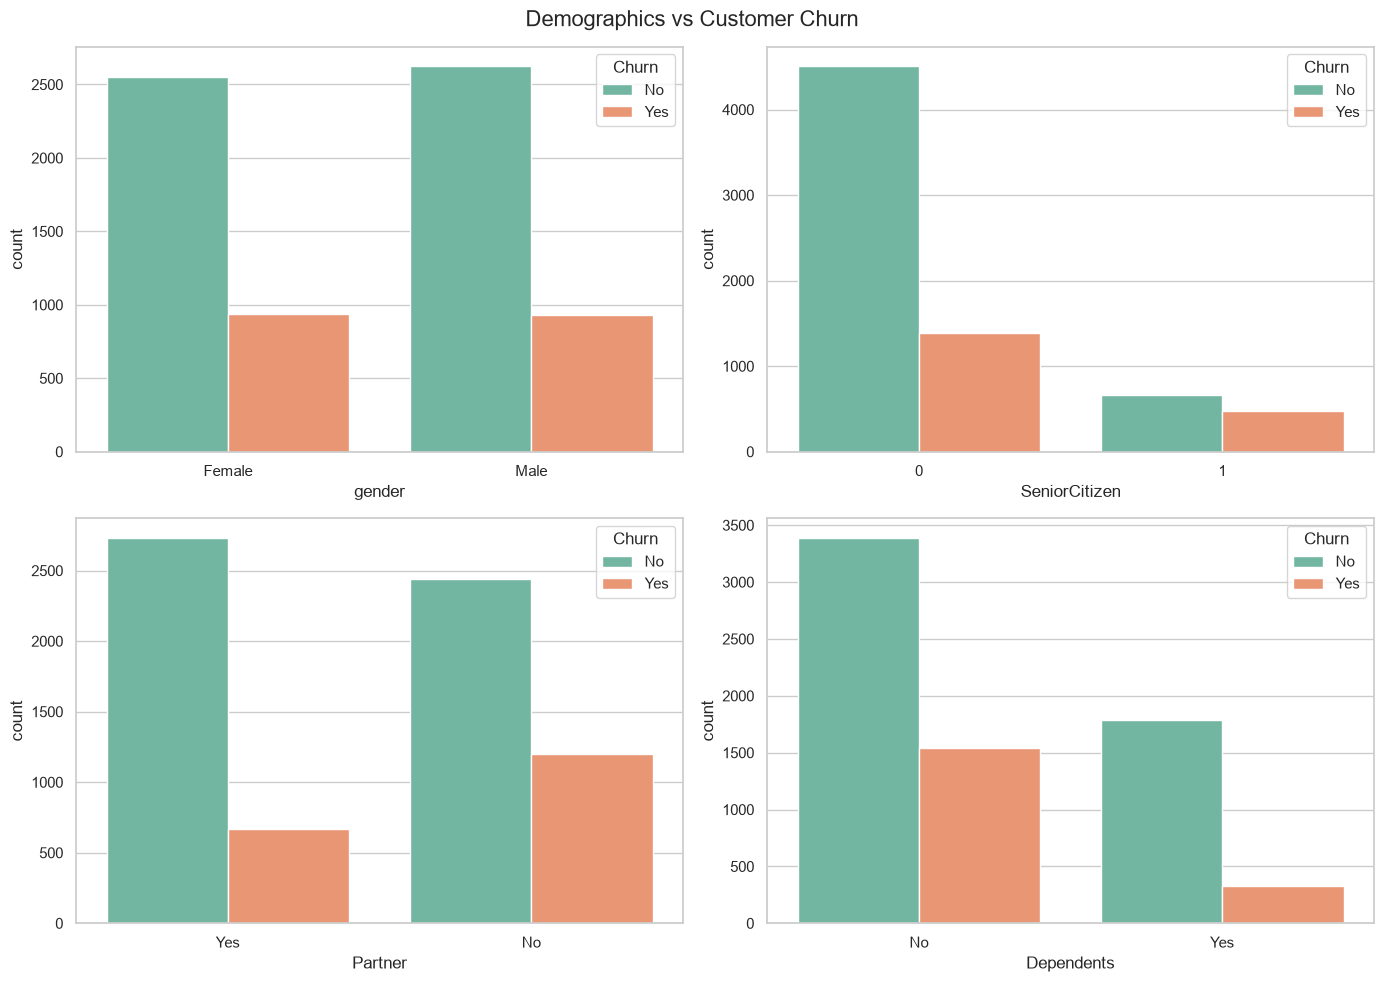

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.countplot(x='gender', hue='Churn', data=df, ax=axes[0,0], palette='Set2')
sns.countplot(x='SeniorCitizen', hue='Churn', data=df, ax=axes[0,1], palette='Set2')
sns.countplot(x='Partner', hue='Churn', data=df, ax=axes[1,0], palette='Set2')
sns.countplot(x='Dependents', hue='Churn', data=df, ax=axes[1,1], palette='Set2')
plt.suptitle('Demographics vs Customer Churn', fontsize=16)
plt.tight_layout()
plt.show()

## 4. Contract and Account Features vs Churn

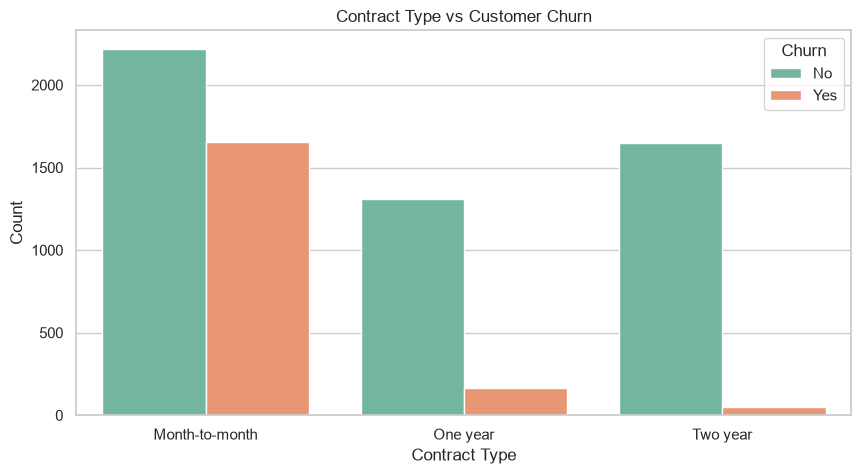

In [18]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')
plt.title('Contract Type vs Customer Churn')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()

## 5. Numeric Features: Distribution and Correlation

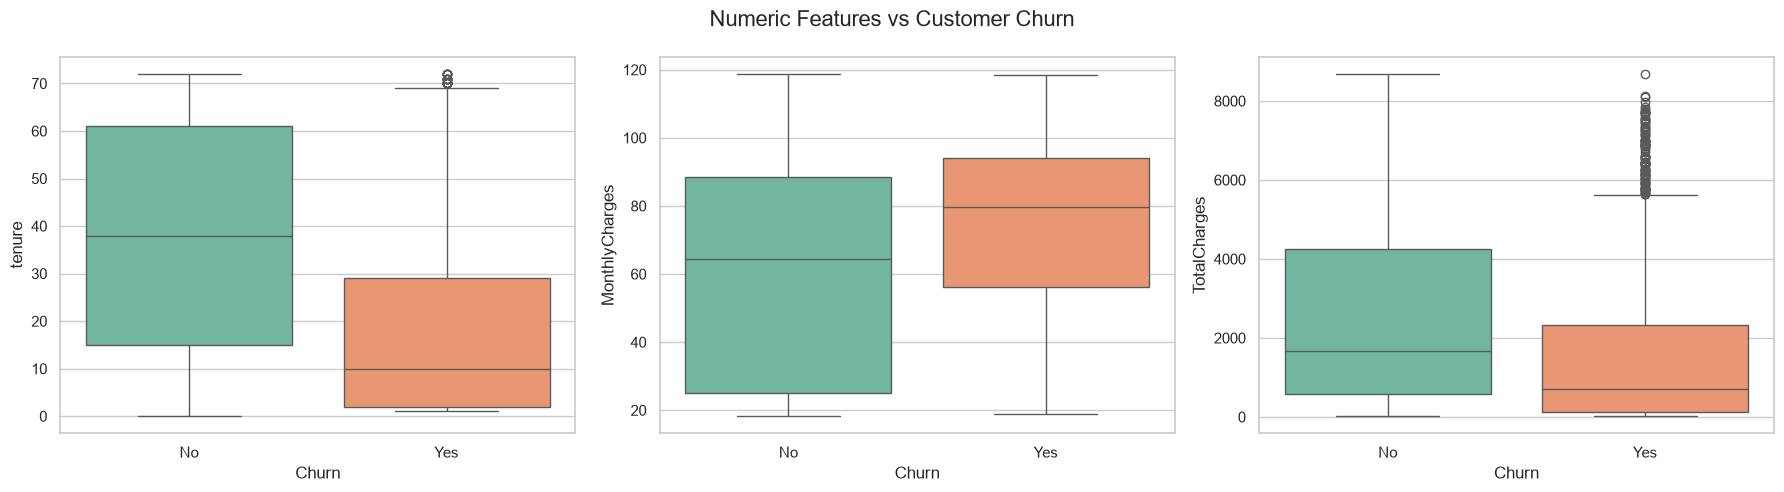

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[0], palette='Set2', hue='Churn', legend=False)
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1], palette='Set2', hue='Churn', legend=False)
sns.boxplot(x='Churn', y='TotalCharges', data=df, ax=axes[2], palette='Set2', hue='Churn', legend=False)
plt.suptitle('Numeric Features vs Customer Churn', fontsize=16)
plt.tight_layout()
plt.show()